In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\anant\OneDrive\Desktop\IRIS.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [4]:
df.duplicated().sum() 

np.int64(0)

In [5]:
#label encoding
from sklearn.preprocessing import LabelEncoder

In [6]:
# Initialize the encoder
le = LabelEncoder()

# Apply encoding on the target column
df['species_encoded'] = le.fit_transform(df['Species'])

print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  


In [7]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species_encoded
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


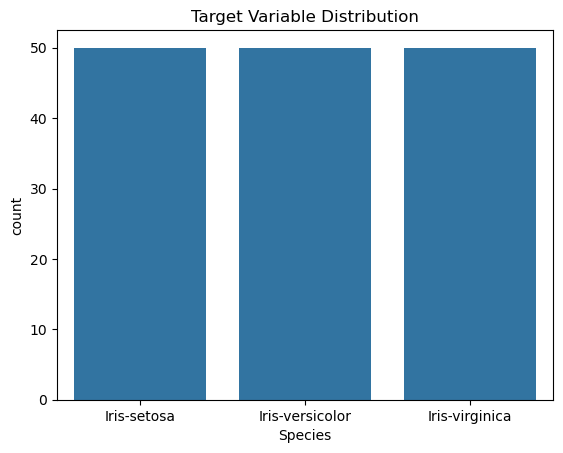

In [8]:
sns.countplot(x='Species', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [9]:
#data is balanced

In [10]:
#here the more amount of data is nonlinear so spearman correlation is applied
feature_target_corr = df.corr(method='spearman')['species_encoded'].sort_values(ascending=False)

print("Correlation of features with target:")
print(feature_target_corr)

ValueError: could not convert string to float: 'Iris-setosa'

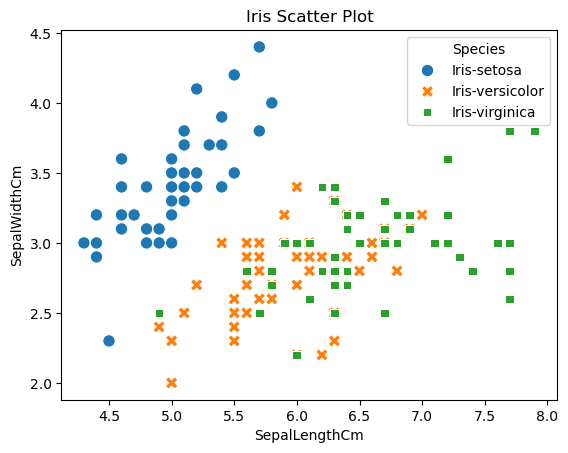

In [14]:
#scatter plot whether we can seperate linearly or not with SVM
sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species",
    style="Species",
    s=80
)

plt.title("Iris Scatter Plot")
plt.show()


In [15]:
#it is a multiclass which cannot be linear seperalble so we use polynomial kernal for the svm to seperate in higher dimension

In [16]:
# Dependent variable (target)
y = df['Species']

# Independent variables (features)
X = df[['PetalWidthCm', 'PetalLengthCm', 'SepalLengthCm']]

In [18]:
# Scale features for better KNN performance
from sklearn.preprocessing import LabelEncoder, StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
# Split into train-test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [22]:
#Applying SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [24]:
#Create SVM with Polynomial Kernel
svc_poly = SVC(
    kernel='poly',
    degree=3,          # degree of the polynomial (you can change)
    C=1.0,             # regularization
    gamma='scale'      # kernel coefficient
)

In [25]:
# Fit the model
svc_poly.fit(X_train, y_train)


SVC(kernel='poly')

In [26]:
# Predict
y_pred = svc_poly.predict(X_test)


In [27]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.77      1.00      0.87        10
 Iris-virginica       1.00      0.70      0.82        10

       accuracy                           0.90        30
      macro avg       0.92      0.90      0.90        30
   weighted avg       0.92      0.90      0.90        30



In [28]:
#checking overfitting

In [31]:
# Training accuracy
train_pred = svc_poly.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Testing accuracy
test_pred = svc_poly.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9416666666666667
Testing Accuracy: 0.9


In [32]:
#no overfitting

In [33]:
#The model Predicted well